# Submission 1 knob sweep — every combination, scored against the ground truth
### ME 323 Module 1, faculty notebook (staff only — not for students)

Submission 1's optional final exercise asks students to sweep every knob
combination — four lanes, two kernels, several noise values, both acquisition
rules, and a few ψ values — collect each run's final coordinates into a
table, save a CSV, and plot where the picks land. This notebook is the staff
run of that sweep, plus the one thing students cannot do: every pick is scored
against the **frozen ground-truth model** (`gpr_str_matern_cal`, the
2026-07-21 full-data-physics-calibration re-freeze recorded in
`ground_truth.py`, refit here on all 85 usable 150 mm tests). It answers,
before any student submits: which knobs actually move the design, which
combinations land on good beams, and what the spread of outcomes looks like.

**Staff only** because it consumes `ibeam150_master.csv` (the full campaign)
and the GT recipe — both on the keep-away-from-students list in
`ground_truth.py`.

**Outputs.** `submission1_knob_sweep.csv` (one row per combination: knob
settings, final coordinates, the model's own prediction, and the GT central
prediction there), four figures (one-knob-at-a-time picks, full-sweep picks
by knob, knob importance, GT-outcome histogram), and a findings summary at
the end. Runs in ≈ 1 min (numpy, pandas, scikit-learn, scipy, matplotlib).

**The sweep grid** — every knob from the Submission 1 dashboard, fully
crossed:

| knob | levels | count |
|---|---|---|
| lane (`CHOICE`) | A plain, B strength, C features, D residual | 4 |
| kernel (`KERNEL`) | RBF, Matérn (ν = 2.5) | 2 |
| assumed noise (`NOISE_PCT`) | 1, 3, 5, 10 % | 4 |
| decision rule (`ACQ` + `psi`) | MUI ψ = 0, 0.5, 1, 2; EI | 5 |

4 × 2 × 4 × 5 = **160 combinations**, each optimized on the student grid
(`linspace(1, 7, 63) × linspace(5, 16, 60)`). Noise levels follow the memo's
stress-test values (1 and 10 %) plus the class default 3 % and the deliberate
smoother 5 %; ψ spans pure exploit (0) to corner-chasing (2). ψ is a knob only
under MUI, so rule and ψ are folded into one five-level factor.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry and class calibration -- identical to Submission 1
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm)
KMASS = 0.2045                    # g/mm^2 of cross-section at 172 mm
SY_CAL, K_CAL, TAU_CAL = 6.683e+07, 0.377, 1.676e+07   # Pre-lab 1 calibration
E, G = 2.5e9, 2.5e9 / 2.6
C1, C2 = 1.35, 0.55

RAW = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/")
def load(name):
    try:
        d = pd.read_csv(RAW + name); src = "GitHub"
    except Exception:
        d = pd.read_csv("../../data/" + name); src = "local copy"
    print(f"{name}: {len(d)} rows ({src})")
    return d

def estimated_mass_g(b, H):
    return KMASS * (b * H + B * (TH - H))

# the 17 beams students model in Submission 1: 15-beam handout + the two
# frozen class-query results (values from ground_truth.py)
df = load("student_beams_B10_L150.csv").rename(columns={"b_mm": "b",
                                                        "H_web_mm": "H"})
df = pd.concat([df, pd.DataFrame([
    dict(beam_id=16, b=1.10, H=13.25, strength_N=475.7),
    dict(beam_id=17, b=1.00, H=13.39, strength_N=445.8)])],
    ignore_index=True)
df["str_to_weight"] = df.strength_N / estimated_mass_g(df.b, df.H)
BEST_TESTED = float(df.str_to_weight.max())
print(len(df), "beams; incumbent best", round(BEST_TESTED, 2), "N/g")

student_beams_B10_L150.csv: 15 rows (GitHub)
17 beams; incumbent best 37.47 N/g


## 1. The student pipeline, verbatim

Physics, GP machinery, lanes, and the acquisition rules below are copied
unchanged from `ME323_Module1_Submission1_Design_KEY.ipynb`, so every run of
the sweep is exactly one setting of the student notebook's dashboard.

In [2]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    def J_rect(x, y):
        short, long_ = min(x, y), max(x, y)
        r = short/long_
        beta = 1 - 0.63*r + 0.052*r**5
        return (1/3)*beta*long_*short**3
    J = J_rect(b_, h_) + 2*J_rect(tf_, B_)
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c, b=b_, h=h_, tf=tf_, B=B_)

def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)
def Q_flange(p):
    return p["B"]*p["tf"]*(p["h"]/2 + p["tf"]/2)
def P_sep(p, tau_i):
    return 2*tau_i*p["Ix"]*p["b"]/Q_flange(p)
def capacity(b, H, sy, k, tau_i):
    p = section_props(b, H)
    return min(P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k))
def gov_mode(b, H, sy, k, tau_i):
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k)
    return "separation" if Ps < min(Pb, Pl) else (
        "LTB" if Pl < 0.999*Pb else "bend")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as CK, RBF, Matern

def make_kernel(kernel, ndim):
    if kernel == "RBF":
        return CK(1.0, (1e-3, 1e3)) * RBF([1.0]*ndim, (1e-1, 30.0))
    elif kernel == "Matern":
        return CK(1.0, (1e-3, 1e3)) * Matern([1.0]*ndim, (1e-1, 30.0), nu=2.5)
    raise ValueError(f"unknown kernel {kernel!r}")

def build_feats(bq, Hq, feats):
    bq, Hq = np.atleast_1d(np.asarray(bq, float)), np.atleast_1d(np.asarray(Hq, float))
    cols = {"b": bq, "H": Hq}
    if "logP" in feats or "stab" in feats:
        pp = [section_props(b, H) for b, H in zip(bq, Hq)]
        Pb = np.array([P_bend(p, SY_CAL) for p in pp])
        Pl = np.array([P_LTB(p, SY_CAL, K_CAL) for p in pp])
        Ps = np.array([P_sep(p, TAU_CAL) for p in pp])
        cols["logP"] = np.log(np.minimum(Pb, np.minimum(Ps, Pl)))
        cols["stab"] = Pl/Pb
    return np.column_stack([cols[f] for f in feats])

def fit_gp(data, alpha=0.03**2, feats=("b", "H"), target="log_sw", kernel="RBF"):
    X = data[list(feats)].values.astype(float)
    fmu, fsd = X.mean(0), X.std(0) + 1e-12
    if target == "log_sw":
        y = np.log(data.strength_N.values /
                   estimated_mass_g(data.b.values, data.H.values))
    elif target == "log_strength":
        y = np.log(data.strength_N.values.astype(float))
    else:                                    # log residual vs calibrated physics
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(data.b, data.H)])
        y = np.log(data.strength_N.values) - np.log(Pphys)
    ymean = y.mean()
    gp = GaussianProcessRegressor(make_kernel(kernel, X.shape[1]), alpha=alpha,
                                  normalize_y=False,
                                  n_restarts_optimizer=5, random_state=0)
    gp.fit((X - fmu) / fsd, y - ymean)
    return gp, fmu, fsd, ymean

def predict_sw(gp, fmu, fsd, ymean, bq, Hq, target, feats):
    Xq = build_feats(bq, Hq, feats)
    mu, sd = gp.predict((Xq - fmu)/fsd, return_std=True)
    mu = mu + ymean
    mass = estimated_mass_g(np.asarray(bq, float), np.asarray(Hq, float))
    if target == "log_sw":
        sw = np.exp(mu)
    elif target == "log_strength":
        sw = np.exp(mu)/mass
    else:
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(np.atleast_1d(bq), np.atleast_1d(Hq))])
        sw = Pphys*np.exp(mu)/mass
    return sw, sd

LANES = {
    "A plain":    dict(feats=("b", "H"), target="log_sw"),
    "B strength": dict(feats=("b", "H"), target="log_strength"),
    "C features": dict(feats=("b", "H", "logP", "stab"), target="log_sw"),
    "D residual": dict(feats=("b", "H"), target="log_residual"),
}

def fit_lane(data, lane, alpha=0.03**2, kernel="RBF"):
    cfg = LANES[lane]
    d2 = data.copy()
    Xf = build_feats(d2.b.values, d2.H.values, cfg["feats"])
    for j, f in enumerate(cfg["feats"]):
        d2[f] = Xf[:, j]
    gp, fmu, fsd, ymean = fit_gp(d2, alpha=alpha, feats=cfg["feats"],
                                 target=cfg["target"], kernel=kernel)
    return gp, fmu, fsd, ymean, cfg

## 2. Run the sweep

One GP fit per (lane, kernel, noise) triple — 32 fits — then all five decision
rules read each fitted surface, since the rules only post-process the same
posterior. Each row records the knob settings, the final coordinates, the
model's own prediction at its pick (`pred_sw`, N/g), the epistemic sigma
there (log units), and the calibrated-physics governing mode.

In [3]:
from scipy.stats import norm

bg = np.linspace(1.0, 7.0, 63); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)

NOISES = [1, 3, 5, 10]
RULES = [("MUI", 0.0), ("MUI", 0.5), ("MUI", 1.0), ("MUI", 2.0), ("EI", None)]

rows = []
for lane in LANES:
    for kernel in ("RBF", "Matern"):
        for noise in NOISES:
            gp, fmu, fsd, ym, cfg = fit_lane(df, lane, alpha=(noise/100)**2,
                                             kernel=kernel)
            SW, SD = predict_sw(gp, fmu, fsd, ym, BB.ravel(), HH.ravel(),
                                cfg["target"], cfg["feats"])
            MU, STD = SW.reshape(BB.shape), SD.reshape(BB.shape)
            for acq, psi in RULES:
                if acq == "MUI":
                    score = np.log(MU) + psi*STD
                    rule = f"MUI psi={psi:g}"
                else:                          # EI over the incumbent best
                    z = (np.log(MU) - np.log(BEST_TESTED)) / STD
                    score = STD * (z*norm.cdf(z) + norm.pdf(z))
                    rule = "EI"
                i = np.unravel_index(np.argmax(score), score.shape)
                bf, Hf = float(BB[i]), float(HH[i])
                rows.append(dict(lane=lane, kernel=kernel, noise_pct=noise,
                                 rule=rule, b_mm=round(bf, 3),
                                 H_web_mm=round(Hf, 3),
                                 pred_sw=round(float(MU[i]), 2),
                                 sigma_log=round(float(STD[i]), 4),
                                 phys_mode=gov_mode(bf, Hf, SY_CAL, K_CAL,
                                                    TAU_CAL)))
    print(f"{lane}: done")
sweep = pd.DataFrame(rows)
n_unique = len(sweep[["b_mm", "H_web_mm"]].drop_duplicates())
print(f"\n{len(sweep)} combinations -> {n_unique} distinct final designs")

A plain: done


B strength: done


C features: done


D residual: done

160 combinations -> 46 distinct final designs


## 3. Score every pick with the ground truth

The scorer is `gpr_str_matern_cal` — the frozen GT of the 2026-07-21
re-freeze: junction-shear physics calibrated on the full GT training pool
(σ_y = 65.242 MPa, k = 0.4246, τᵢ = 21.056 MPa), with a Matérn ν = 2.5 GP on
`(b, H_web)` learning `log(strength / P_phys)`, α = 0.03², refit here on the
85 usable master tests (86 minus the one censored LTB test). Reported is the
GT **central prediction**: `P_phys · exp(latent mean)`, i.e. the posterior
*median* on the response scale — the same quantity the frozen class queries
returned (per `ground_truth.py`), noiseless.

Before trusting the refit, it is checked against the two frozen class-query
values. Match within rounding = the refit reproduces the frozen model.
The GT physics constants are the *full-data* calibration, deliberately
different from the Pre-lab 1 class calibration (66.8 MPa, 0.377, 16.76 MPa)
fit on the 15-beam handout. Note for interpreting the lane comparison below:
this GT is itself a residual-on-calibrated-physics model — the same
formulation as student lane D, differing in its calibration data.

In [4]:
# GT physics: junction-shear capacity at the FULL-DATA calibration
# (NOT the Pre-lab 1 class calibration) -- per ground_truth.py, 2026-07-21
SY_GT, K_GT, TAU_GT = 65.242e6, 0.424578, 21.056e6

def gt_pphys(b, H):
    b, H = np.atleast_1d(np.asarray(b, float)), np.atleast_1d(np.asarray(H, float))
    return np.array([capacity(bb, hh, SY_GT, K_GT, TAU_GT)
                     for bb, hh in zip(b, H)])

master = load("ibeam150_master.csv").rename(columns={"b_mm": "b",
                                                     "H_web_mm": "H"})
allt = master[~master.censored].reset_index(drop=True)
print(f"GT training pool: {len(allt)} usable tests "
      f"({int(master.censored.sum())} censored excluded)")

Xg = np.column_stack([allt.b.values, allt.H.values])
yg = np.log(allt.strength_N.values) - np.log(gt_pphys(allt.b.values,
                                                      allt.H.values))
GT_FMU, GT_FSD = Xg.mean(0), Xg.std(0) + 1e-12
GT_YM = yg.mean()
gt_gp = GaussianProcessRegressor(
    CK(1.0, (1e-3, 1e3)) * Matern([1.0]*2, (1e-2, 30.0), nu=2.5),
    alpha=0.03**2, normalize_y=False, n_restarts_optimizer=5, random_state=0)
gt_gp.fit((Xg - GT_FMU)/GT_FSD, yg - GT_YM)

def gt_central(b, H):
    """GT central prediction: (strength_N, str/w). P_phys * exp(latent mean)
    = posterior median on the response scale, matching the frozen queries."""
    b, H = np.atleast_1d(np.asarray(b, float)), np.atleast_1d(np.asarray(H, float))
    Xq = np.column_stack([b, H])
    mu = gt_gp.predict((Xq - GT_FMU)/GT_FSD) + GT_YM
    sN = gt_pphys(b, H) * np.exp(mu)
    return sN, sN / estimated_mass_g(b, H)

# --- validation: does the refit reproduce the frozen class-query values? ---
print("\nvalidation against ground_truth.py frozen values:")
ok = True
for name, bq, Hq, want_N in [("equation beam 16", 1.10, 13.25, 475.7),
                             ("GP beam 17",       1.00, 13.39, 445.8)]:
    sN, ssw = gt_central(bq, Hq)
    flag = "PASS" if abs(sN[0] - want_N) < 2.0 else "MISMATCH"
    ok &= flag == "PASS"
    print(f"  {name}: refit {sN[0]:6.1f} N ({ssw[0]:.2f} N/g)  "
          f"frozen {want_N} N  [{flag}]")
if not ok:
    print("  ** refit does not reproduce the frozen GT (library-version "
          "drift?) -- GT columns below are suspect **")

# GT optimum on the student grid, for reference lines
_, gsw_grid = gt_central(BB.ravel(), HH.ravel())
gi = int(np.argmax(gsw_grid))
GT_OPT_SW, GT_OPT_B, GT_OPT_H = float(gsw_grid[gi]), float(BB.ravel()[gi]), float(HH.ravel()[gi])
print(f"\nGT optimum on the student grid: {GT_OPT_SW:.2f} N/g "
      f"at (b = {GT_OPT_B:.2f}, H_web = {GT_OPT_H:.2f})")

sN, ssw = gt_central(sweep.b_mm.values, sweep.H_web_mm.values)
sweep["gt_strength_N"] = np.round(sN, 1)
sweep["gt_sw"] = np.round(ssw, 2)
sweep["gt_gap"] = np.round(GT_OPT_SW - sweep.gt_sw, 2)   # N/g left on the table

sweep.to_csv("submission1_knob_sweep.csv", index=False)
print(f"\nwrote submission1_knob_sweep.csv ({len(sweep)} rows)")

DEFAULT = dict(lane="A plain", kernel="RBF", noise_pct=3, rule="MUI psi=1")
mask = np.logical_and.reduce([sweep[k] == v for k, v in DEFAULT.items()])
drow = sweep[mask].iloc[0]
print(f"default recipe (A plain, RBF, 3%, MUI psi=1) -> "
      f"({drow.b_mm:.2f}, {drow.H_web_mm:.2f}), GT {drow.gt_sw:.2f} N/g")
print(f"combos whose pick GT-scores >= incumbent {BEST_TESTED:.2f} N/g: "
      f"{(sweep.gt_sw >= BEST_TESTED).mean()*100:.0f}%")
print("corr(pred_sw at pick, gt_sw at pick) across combos: "
      f"{np.corrcoef(sweep.pred_sw, sweep.gt_sw)[0,1]:+.2f}")

print("\ntop 10 combinations by GT outcome:")
print(sweep.sort_values("gt_sw", ascending=False).head(10)
      [["lane", "kernel", "noise_pct", "rule", "b_mm", "H_web_mm",
        "pred_sw", "gt_sw", "phys_mode"]].to_string(index=False))

ibeam150_master.csv: 86 rows (GitHub)
GT training pool: 85 usable tests (1 censored excluded)



validation against ground_truth.py frozen values:
  equation beam 16: refit  475.7 N (37.48 N/g)  frozen 475.7 N  [PASS]
  GP beam 17: refit  445.8 N (36.65 N/g)  frozen 445.8 N  [PASS]



GT optimum on the student grid: 42.13 N/g at (b = 1.39, H_web = 12.08)



wrote submission1_knob_sweep.csv (160 rows)
default recipe (A plain, RBF, 3%, MUI psi=1) -> (1.39, 14.88), GT 33.06 N/g
combos whose pick GT-scores >= incumbent 37.47 N/g: 22%
corr(pred_sw at pick, gt_sw at pick) across combos: -0.12

top 10 combinations by GT outcome:
      lane kernel  noise_pct        rule  b_mm  H_web_mm  pred_sw  gt_sw phys_mode
D residual    RBF          3   MUI psi=0 1.387    11.712    42.47  40.83      bend
D residual Matern          3   MUI psi=2 1.387    11.712    41.59  40.83      bend
D residual Matern          1   MUI psi=1 1.387    11.712    42.56  40.83      bend
D residual Matern          1   MUI psi=2 1.387    11.712    42.56  40.83      bend
D residual Matern          1          EI 1.387    11.712    42.56  40.83      bend
D residual Matern          3   MUI psi=0 1.387    11.712    41.59  40.83      bend
D residual Matern          3 MUI psi=0.5 1.387    11.712    41.59  40.83      bend
D residual    RBF          3 MUI psi=0.5 1.387    11.712    42.47

## 4. Where the designs end up

Two views of the same design box, all axes in (b, H_web) mm. Gray dots are the
17 beams the models were fit to; the black star is the GT-grid optimum. Marker
**shape and color together** encode the knob level (colors are from the
colorblind-safe Okabe–Ito set; noise, being ordered, gets a light→dark
single-hue ramp).

**Figure 1 — one knob at a time.** Start from the student default recipe
(lane A, RBF, 3 % noise, MUI ψ = 1) and move a single knob per panel, holding
the other three at the default. Coincident picks are drawn nested (larger
markers behind smaller), so a panel showing one visible stack means the knob
did not move the design.

**Figure 2 — the full factorial, marginal by knob.** All 160 picks appear in
every panel; each panel colors them by a different knob. Marker area scales
with the number of combinations sharing that level at that grid point. A knob
whose colors separate into distinct clusters is doing real work; a knob whose
colors stack on the same spots is not.

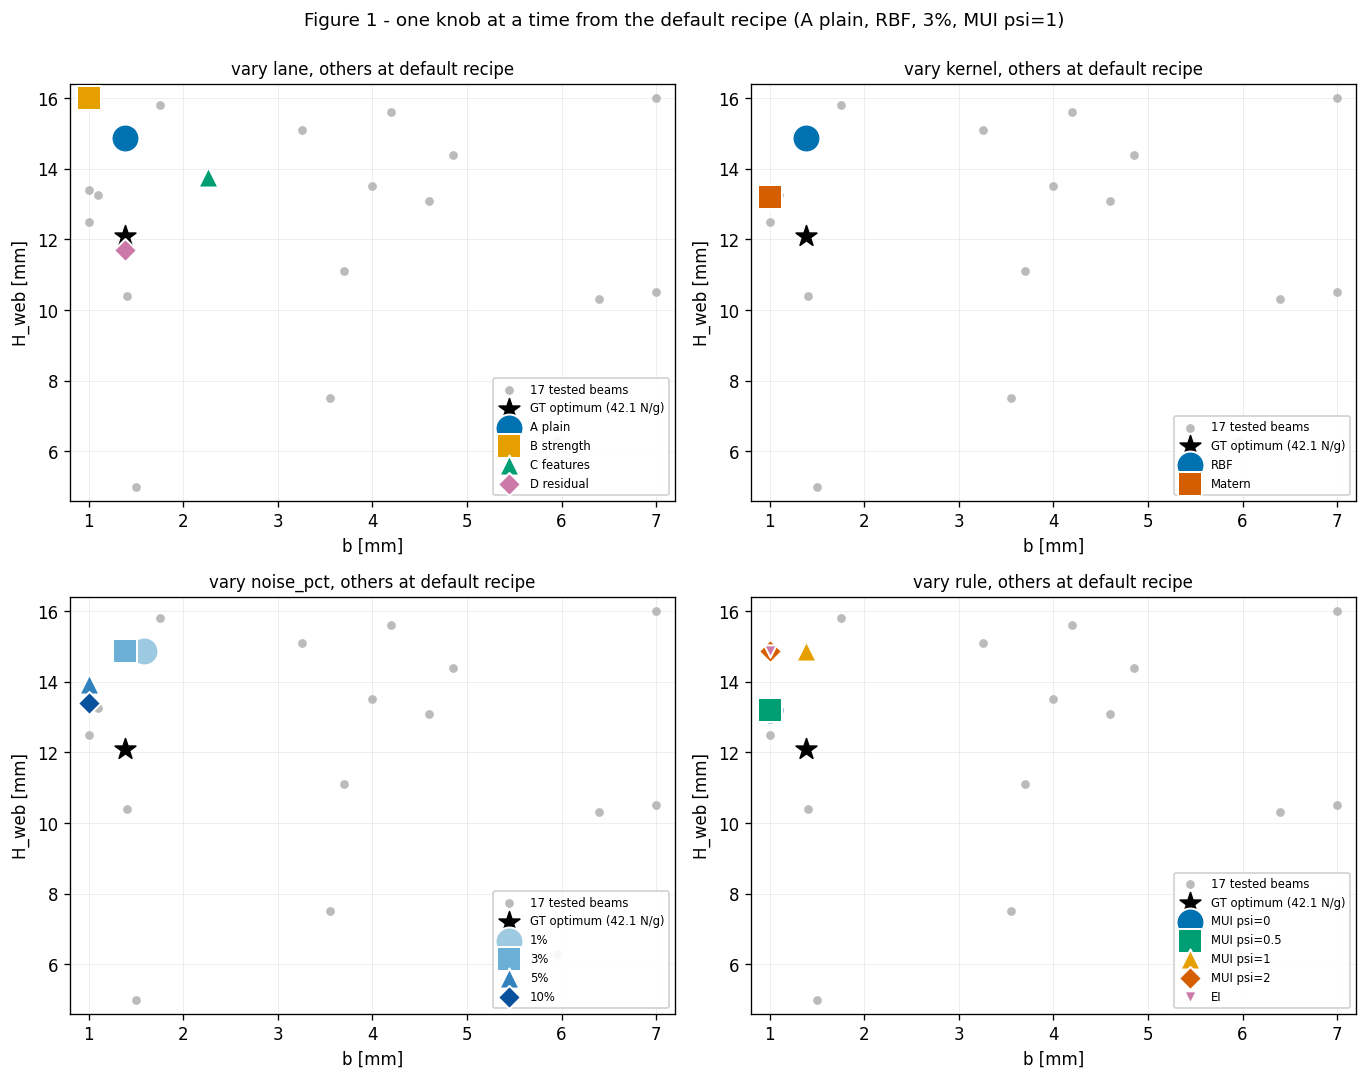

In [5]:
# styling: Okabe-Ito categorical colors; single-hue ramp for the ordered
# noise knob; shapes double-encode every level (color-vision-deficiency safe)
LANE_STYLE  = {"A plain": ("#0072B2", "o"), "B strength": ("#E69F00", "s"),
               "C features": ("#009E73", "^"), "D residual": ("#CC79A7", "D")}
KERN_STYLE  = {"RBF": ("#0072B2", "o"), "Matern": ("#D55E00", "s")}
NOISE_STYLE = {1: ("#9ecae1", "o"), 3: ("#6baed6", "s"),
               5: ("#3182bd", "^"), 10: ("#08519c", "D")}
RULE_STYLE  = {"MUI psi=0": ("#0072B2", "o"), "MUI psi=0.5": ("#009E73", "s"),
               "MUI psi=1": ("#E69F00", "^"), "MUI psi=2": ("#D55E00", "D"),
               "EI": ("#CC79A7", "v")}
KNOBS = [("lane", LANE_STYLE), ("kernel", KERN_STYLE),
         ("noise_pct", NOISE_STYLE), ("rule", RULE_STYLE)]

def draw_context(a):
    a.scatter(df.b, df.H, c="#bbbbbb", s=18, zorder=1, label="17 tested beams")
    a.scatter([GT_OPT_B], [GT_OPT_H], marker="*", c="k", s=170, zorder=6,
              label=f"GT optimum ({GT_OPT_SW:.1f} N/g)")
    a.set_xlim(0.8, 7.2); a.set_ylim(4.6, 16.4)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]")
    a.grid(alpha=0.25, linewidth=0.5)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 9))
for a, (knob, style) in zip(axes.ravel(), KNOBS):
    draw_context(a)
    sizes = [280, 205, 145, 95, 55]          # nested so coincident picks show
    for lvl_i, (lvl, (col, mk)) in enumerate(style.items()):
        sel = {k: v for k, v in DEFAULT.items() if k != knob} | {knob: lvl}
        r = sweep[np.logical_and.reduce([sweep[k] == v
                                         for k, v in sel.items()])].iloc[0]
        lab = f"{lvl}%" if knob == "noise_pct" else str(lvl)
        a.scatter(r.b_mm, r.H_web_mm, marker=mk, s=sizes[lvl_i],
                  facecolor=col, edgecolor="white", linewidth=1.2,
                  zorder=3 + lvl_i, label=lab)
    a.set_title(f"vary {knob}, others at default recipe", fontsize=10)
    a.legend(fontsize=7, loc="lower right", framealpha=0.9)
fig.suptitle("Figure 1 - one knob at a time from the default recipe "
             "(A plain, RBF, 3%, MUI psi=1)", y=0.995, fontsize=11)
plt.tight_layout(); plt.show()

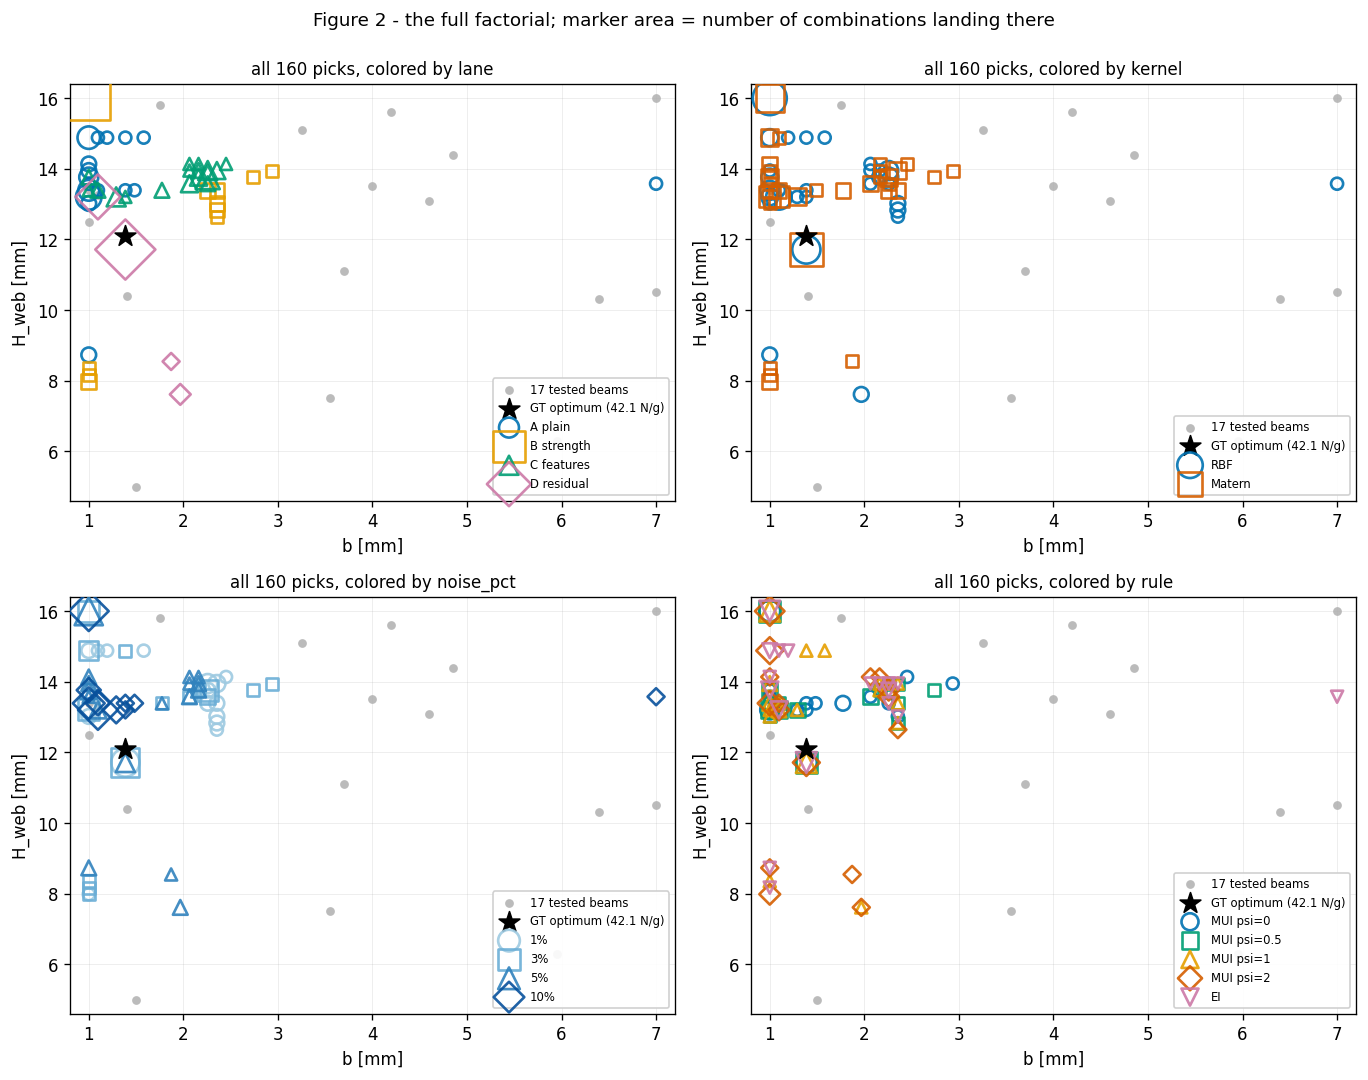

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9))
for a, (knob, style) in zip(axes.ravel(), KNOBS):
    draw_context(a)
    for lvl, (col, mk) in style.items():
        g = (sweep[sweep[knob] == lvl]
             .groupby(["b_mm", "H_web_mm"]).size().reset_index(name="n"))
        lab = f"{lvl}%" if knob == "noise_pct" else str(lvl)
        a.scatter(g.b_mm, g.H_web_mm, marker=mk, s=26 + 26*g.n,
                  facecolor="none", edgecolor=col, linewidth=1.6,
                  alpha=0.9, zorder=3, label=lab)
    a.set_title(f"all 160 picks, colored by {knob}", fontsize=10)
    a.legend(fontsize=7, loc="lower right", framealpha=0.9)
fig.suptitle("Figure 2 - the full factorial; marker area = number of "
             "combinations landing there", y=0.995, fontsize=11)
plt.tight_layout(); plt.show()

## 5. Which knobs matter, and how the outcomes distribute

**Knob importance** is measured directly from the factorial: for each knob,
hold the other three fixed (40 such settings per knob... precisely, one per
combination of the others), toggle the knob through its levels, and record
(a) the largest distance between the resulting picks in design space and
(b) the spread in GT outcome. Averaging over all settings of the other knobs
gives the two bars below — movement is *causal* for that knob, not
correlational.

**The histogram** answers the bottom-line question: a group runs the
Submission 1 pipeline with *some* defensible knob recipe and prints whatever
it recommends — what str/w does the ground truth say their beam actually has?
It counts combinations (160), not distinct designs, so a tall bar means many
recipes converge on picks of that quality. Reference lines mark the incumbent
best tested beam, the default recipe's pick, and the GT-grid optimum.
Caveat for reading small differences: the GT model's own leave-one-location-out
RMSE is ≈ 2.4 N/g, so gaps under about 2 N/g between combos are within the
scorer's noise floor.

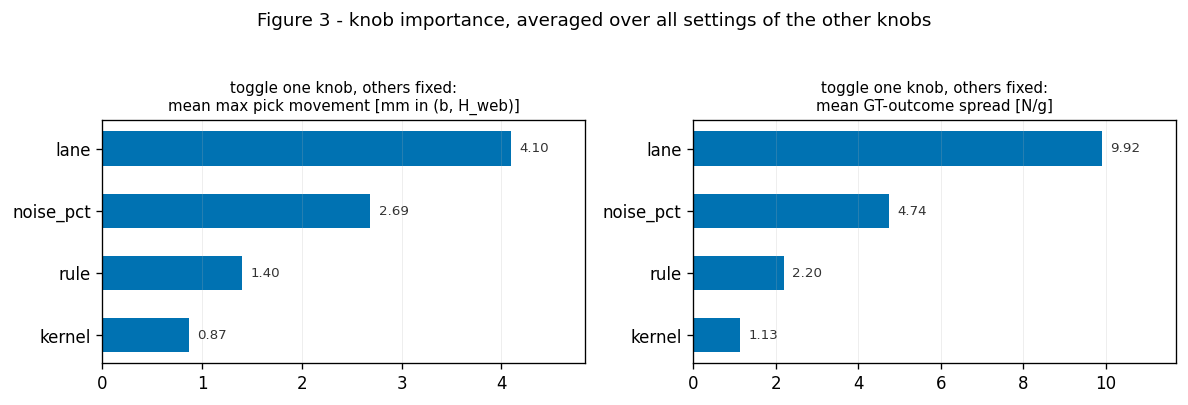

     knob  move_mm  gt_range
     lane     4.10      9.92
noise_pct     2.69      4.74
     rule     1.40      2.20
   kernel     0.87      1.13


In [7]:
imp = []
for knob, _ in KNOBS:
    others = [k for k, _ in KNOBS if k != knob]
    moves, swr = [], []
    for _, g in sweep.groupby(others):
        pts = g[["b_mm", "H_web_mm"]].values
        dist = np.sqrt(((pts[:, None, :] - pts[None, :, :])**2).sum(-1))
        moves.append(dist.max())
        swr.append(g.gt_sw.max() - g.gt_sw.min())
    imp.append(dict(knob=knob, move_mm=np.mean(moves), gt_range=np.mean(swr)))
imp = pd.DataFrame(imp).sort_values("move_mm")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for a, colname, ttl in [(ax[0], "move_mm",
                         "mean max pick movement [mm in (b, H_web)]"),
                        (ax[1], "gt_range",
                         "mean GT-outcome spread [N/g]")]:
    a.barh(imp.knob, imp[colname], color="#0072B2", height=0.55)
    for y, v in enumerate(imp[colname]):
        a.text(v + 0.02*imp[colname].max(), y, f"{v:.2f}", va="center",
               fontsize=8, color="#333333")
    a.set_title(f"toggle one knob, others fixed:\n{ttl}", fontsize=9)
    a.grid(axis="x", alpha=0.25, linewidth=0.5)
    a.set_xlim(0, imp[colname].max()*1.18)
fig.suptitle("Figure 3 - knob importance, averaged over all settings of the "
             "other knobs", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()
print(imp.sort_values("move_mm", ascending=False).round(2).to_string(index=False))

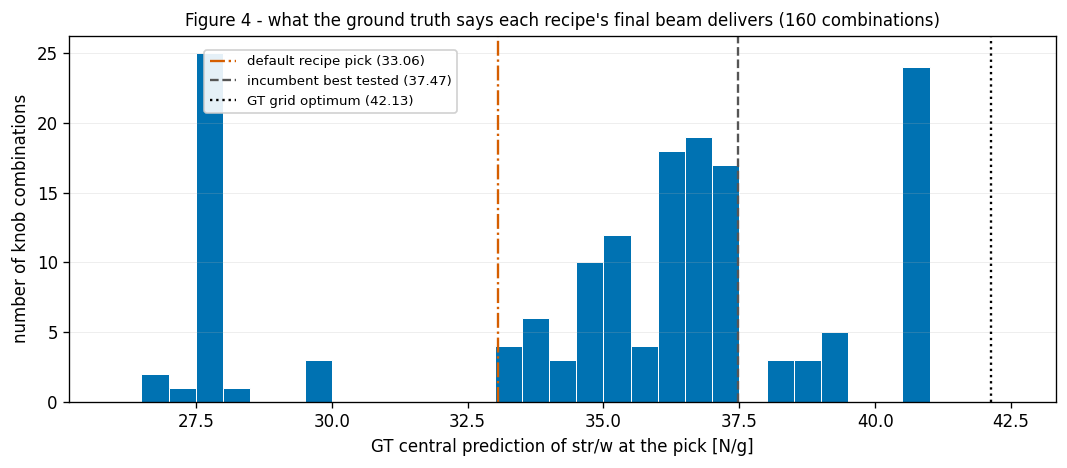

GT outcome quartiles [N/g]: {0.0: 26.58, 0.25: 33.72, 0.5: 36.45, 0.75: 37.43, 1.0: 40.83}

median GT outcome by lane [N/g]:
lane
A plain       36.47
B strength    27.97
C features    35.33
D residual    40.83

median GT outcome by rule [N/g]:
rule
EI             35.06
MUI psi=0      36.69
MUI psi=0.5    36.56
MUI psi=1      36.36
MUI psi=2      35.32

picks on a box edge: 65/160  median GT 33.72 N/g;  interior picks: median GT 37.43 N/g


In [8]:
fig, a = plt.subplots(figsize=(9, 4))
a.hist(sweep.gt_sw, bins=np.arange(26.0, 42.75, 0.5), color="#0072B2",
       edgecolor="white", linewidth=0.6)
for x, lab, col, ls in [
        (float(drow.gt_sw), f"default recipe pick ({drow.gt_sw:.2f})",
         "#D55E00", "-."),
        (BEST_TESTED, f"incumbent best tested ({BEST_TESTED:.2f})",
         "#555555", "--"),
        (GT_OPT_SW, f"GT grid optimum ({GT_OPT_SW:.2f})", "k", ":")]:
    a.axvline(x, color=col, linestyle=ls, linewidth=1.4, label=lab)
a.legend(fontsize=8, loc="upper left", bbox_to_anchor=(0.13, 0.98),
         framealpha=0.9)
a.set_xlabel("GT central prediction of str/w at the pick [N/g]")
a.set_ylabel("number of knob combinations")
a.set_title("Figure 4 - what the ground truth says each recipe's final beam "
            "delivers (160 combinations)", fontsize=10)
a.grid(axis="y", alpha=0.25, linewidth=0.5)
plt.tight_layout(); plt.show()

print("GT outcome quartiles [N/g]:",
      sweep.gt_sw.quantile([0, .25, .5, .75, 1]).round(2).to_dict())
print("\nmedian GT outcome by lane [N/g]:")
print(sweep.groupby("lane").gt_sw.median().round(2).to_string())
print("\nmedian GT outcome by rule [N/g]:")
print(sweep.groupby("rule").gt_sw.median().round(2).to_string())

edge = (np.isclose(sweep.b_mm, 1.0) | np.isclose(sweep.b_mm, 7.0) |
        np.isclose(sweep.H_web_mm, 5.0) | np.isclose(sweep.H_web_mm, 16.0))
print(f"\npicks on a box edge: {edge.sum()}/{len(sweep)}  "
      f"median GT {sweep[edge].gt_sw.median():.2f} N/g;  "
      f"interior picks: median GT {sweep[~edge].gt_sw.median():.2f} N/g")

## 6. Findings

Numbers below are from this notebook's run against the 2026-07-21 frozen GT
(scikit-learn fits are seeded, so reruns reproduce them up to library-version
wobble; the KEY's checkpoint tolerance of ±0.1 N/g applies here too).

**The lane is the design decision; everything else is trim.** Toggling the
lane moves the pick 4.1 mm on average and swings the GT outcome by 9.9 N/g —
more than noise (2.7 mm, 4.7 N/g), the decision rule (1.4 mm, 2.2 N/g), and
the kernel (0.9 mm, 1.1 N/g). The kernel, which students often agonize over,
matters least — matching the KEY's "0.1–0.3 N/g LOO differences are a coin
flip" caveat. The sweep turns that from advice into a measurement.

**Highest-performing combinations: lane D, almost regardless of trim.**
24 of lane D's 40 combos land on (1.39, 11.71) — GT 40.83 N/g, 1.3 N/g off
the GT-grid optimum of 42.13 at (1.39, 12.08) — every lane D pick is
interior, and its worst combo still scores 35.3. Lane D also wins the
students' own 17-beam LOO table, so the honest referee and the hidden answer
key agree — though see caveat 2. Lane A is next (median 36.5), lane C close
behind (35.3); lane B is the tail (median 28.0) and the sharpest lesson in
the sweep, because it is bimodal: its five interior picks near (2.36, 12.8)
GT-score a solid 38.0–39.3, while 25 of its 40 combos pin the minimum-mass
H_web = 16 edge — predicting 39–49 N/g where the GT pays 28.0 — and four
more dive to the thin-everything corner near (1.0, 8.0), where the GT pays
26.6–28.0. Same lane, same data: interior picks fine, edge picks
catastrophic. That is the divide-by-light-mass failure the KEY warns lane B
invites, expressed as geography.

**Edges are where recipes go to die.** 65 of the 160 picks land on a box
edge; their median GT outcome is 33.7 N/g against 37.4 for interior picks.
The GT optimum itself is interior, and the recipes that found its
neighborhood never touched a wall. This is the quantitative backing for the
edge-pick caution now in Pre-lab 2 and Submission 1.

**Optimism carries almost no information.** Across the 160 combos, the
correlation between a recipe's own prediction at its pick and the GT outcome
there is **−0.12** — slightly negative: a recipe being excited about its
design tells you nothing good. The extreme case is lane B's edge pile,
predicting up to 48.9 N/g on a design the GT scores at 28.0. The mechanism
is selection bias — an acquisition maximum is where the model is most wrong
in its own favor.

**The default recipe is mediocre, and now interior-but-poor.** The handout
default (A plain, RBF, 3 %, MUI ψ = 1) picks (1.39, 14.88): GT 33.1 N/g —
the 20th percentile of the sweep, well under both the sweep median of 36.5
and the incumbent 37.47. Only 22 % of all combos GT-score at or above the
incumbent best tested beam: 24 lane-D combos plus a handful of C/A/B combos
on the interior b ≈ 1.3–2.4, H_web ≈ 12.6–13.4 ridge. Exploration appetite
hurts on this map: median GT outcome falls monotonically from ψ = 0 (36.7)
to ψ = 2 (35.3), with EI at the exploratory end (35.1) — with 17 points
already ringing the good ridge, staying home beats corner-chasing.

**Caveats.** (1) All "outcomes" are GT central predictions, not physical
tests; the GT's LOLO RMSE is ≈ 2.4 N/g, so treat sub-2 N/g gaps as ties —
lane D vs everything else clears that bar; the ψ ordering does not by much.
(2) The GT is now *the same formulation as lane D* — a Matérn GP on
log(strength/P_phys) — differing only in its physics calibration (full-data
vs handout) and training pool (85 vs 17 tests). Lane D's margin is therefore
partly family resemblance, and this sweep alone cannot say how much; the
GT-free 17-beam LOO table, where D also wins, is the independent evidence
that the direction is real. (3) The sweep optimizes on the 63 × 60 grid, so
picks snap to grid nodes; movements under one grid step (≈ 0.10 mm in b,
≈ 0.19 mm in H_web) are not resolvable.

**For the module:** the sweep is direct evidence for memo prompt 5's
stress-test and the Decision Card's "which assumption is doing real work"
row — the defensible answer is *the lane* (and within a lane, ψ), not the
kernel. Staff can also use Figure 2 to spot a group whose pick sits outside
every cluster: that flags either a novel argument worth reading or a bug.